In [1]:
import os

import random

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.utils.data as data
import torch.optim as optim
from torch.utils.data import Dataset
from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as transforms
from torchvision.io import decode_image

In [2]:
# Function for setting the seed
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
set_seed(42)

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
device


device(type='cuda', index=0)

## Create dataset and dataloader

In [3]:
class CifarDataset(Dataset):
    def __init__(self, path: str, train: bool = True,transform=None, target_transform=None):
        self.path = os.path.join(path, "train")if train else os.path.join(path, "test")
        self.transform = transform
        self.target_transform = target_transform
        self.data = []
        self.targets = []

        for folder_name in os.listdir(self.path):
            folder_path = os.path.join(self.path, folder_name)
            if os.path.isdir(folder_path):
                for filename in os.listdir(folder_path):
                    file_path = os.path.join(folder_path, filename)
                    self.data.append(file_path)
                    self.targets.append(folder_name)

        self.num_samples = len(self.data)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        img_path = self.data[idx]
        img = Image.open(img_path)
        label = self.targets[idx]
        if self.transform:
            img = self.transform(img)
        if self.target_transform:
            label = self.target_transform(label)
        return img, label

In [4]:
label_map = {
    'airplane': 0,
    'automobile': 1,
    'bird': 2,
    'dog': 3,
    'frog': 4
}

temp_dataset = CifarDataset(path="./cifar_small", train=True, transform=None, target_transform=lambda l: label_map[l])
all_data = torch.stack([transforms.ToTensor()(img) for img, _ in temp_dataset], dim=0)
pixel_mean = all_data.mean(dim=(0, 2, 3))
pixel_std = all_data.std(dim=(0, 2, 3))
print(f"Mean: {pixel_mean}, Std: {pixel_std}")

Mean: tensor([0.4911, 0.4818, 0.4444]), Std: tensor([0.2444, 0.2417, 0.2626])


In [5]:
train_transform = transforms.Compose([transforms.RandomHorizontalFlip(),
                                      transforms.RandomResizedCrop((32,32), scale=(0.8,1.0), ratio=(0.9,1.1)),
                                      transforms.ToTensor(),
                                      transforms.Normalize(pixel_mean, pixel_std)
                                     ])
train_dataset = CifarDataset(path="./cifar_small", transform=train_transform, target_transform=lambda l: label_map[l])

train_set, val_set = torch.utils.data.random_split(train_dataset, [22500, 2500])

train_loader = data.DataLoader(train_set, batch_size=128, shuffle=True, drop_last=True, num_workers=4)
val_loader = data.DataLoader(val_set, batch_size=128, shuffle=False, drop_last=False, num_workers=4)

In [6]:
test_transform = transforms.Compose([transforms.ToTensor(),
                                     transforms.Normalize(pixel_mean, pixel_std)])
images_original = [test_transform(temp_dataset[idx][0]) for idx in range(5)]
images_augmented = [train_transform(temp_dataset[idx][0]) for idx in range(5)]

(-0.5, 171.5, 69.5, -0.5)

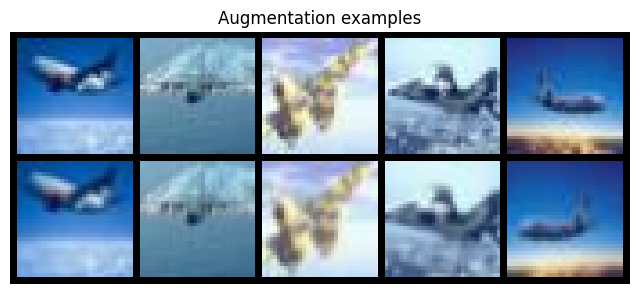

In [7]:
img_grid = torchvision.utils.make_grid(torch.stack(images_original + images_augmented, dim=0), nrow=5, normalize=True)
img_grid = img_grid.permute(1, 2, 0) # CHW to HWC


plt.figure(figsize=(8,8))
plt.title("Augmentation examples")
plt.imshow(img_grid)
plt.axis('off')

## ResNet implementation

In [8]:
class ResNetBottleneckBlock(nn.Module):
    def __init__(self, in_channels: int, bottleneck_width: int, out_channels, stride=1, activation=nn.ReLU):
        super().__init__()
        self.bottleneck_width = bottleneck_width
        self.out_channels = out_channels

        self.compress_bn = nn.BatchNorm2d(in_channels)
        self.compress_act = activation()
        self.compress_conv = nn.Conv2d(in_channels, self.bottleneck_width, kernel_size=1, stride=1, padding=0, bias=False)

        self.process = nn.Sequential(
            nn.BatchNorm2d(self.bottleneck_width),
            activation(),
            nn.Conv2d(self.bottleneck_width, self.bottleneck_width, kernel_size=3, stride=stride, padding=1, bias=False)
        )
        self.expand = nn.Sequential(
            nn.BatchNorm2d(self.bottleneck_width),
            activation(),
            nn.Conv2d(self.bottleneck_width, self.out_channels, kernel_size=1, stride=1, padding=0, bias=False)
        )

        self.shortcut = nn.Identity()
        if stride != 1 or in_channels != self.out_channels:
            self.shortcut = nn.Conv2d(in_channels, self.out_channels, kernel_size=1, stride=stride, bias=False)


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        compressed = self.compress_bn(x)
        compressed = self.compress_act(compressed)
        shortcut = self.shortcut(x)
        compressed = self.compress_conv(compressed)

        processed = self.process(compressed)
        residual = self.expand(processed)

        return shortcut + residual

class ResNetNN(nn.Module):
    def __init__(self, num_classes=1000):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)

        self.layer1 = self._make_layer(16, 64, blocks=3, bottleneck_width=16, stride=1)
        self.layer2 = self._make_layer(64, 128, blocks=3, bottleneck_width=32, stride=2)
        self.layer3 = self._make_layer(128, 256, blocks=3, bottleneck_width=64, stride=2)

        self.bn = nn.BatchNorm2d(256)
        self.relu = nn.ReLU()
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

        for m in self.modules():
            if isinstance(m, ResNetBottleneckBlock):
                nn.init.constant_(m.expand[2].weight, 0)

        
    def _make_layer(self, in_channels, out_channels, blocks, bottleneck_width, stride):
        layers = []

        layers.append(ResNetBottleneckBlock(in_channels, bottleneck_width, out_channels, stride=stride))

        for i in range(1, blocks):
            layers.append(ResNetBottleneckBlock(out_channels, bottleneck_width, out_channels))
        
        return nn.Sequential(*layers)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv1(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.bn(x)
        x = self.relu(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x


In [9]:
first_batch = next(iter(train_loader))

print(f"Input shape: {first_batch[0].shape}")

Input shape: torch.Size([128, 3, 32, 32])


In [10]:
resNetBlock = ResNetNN(5)

In [11]:
output2 = resNetBlock(first_batch[0])
output2.shape

second_batch = next(iter(train_loader))
output2 = resNetBlock(second_batch[0])

In [ ]:
from torch import optim
import torch.nn.functional as F
import torch
from torch.optim.lr_scheduler import ReduceLROnPlateau

def train(model, train_loader, epochs, loss_function, optimizer, device, val_loader, scheduler):
    best_val_loss = float('inf')
    patience = 10  # Stop if no improvement for 10 epochs
    counter = 0    # Counts how many bad epochs in a row
    
    for epoch in range(epochs):
        # --- Training Phase ---
        model.train()  # Always ensure we are in train mode at start of epoch
        running_train_loss = 0.0
        
        for batch, labels in train_loader:
            batch, labels = batch.to(device), labels.to(device)

            optimizer.zero_grad()
            preds = model(batch)
            loss = loss_function(preds, labels)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item()
        
        # Calculate average training loss
        avg_train_loss = running_train_loss / len(train_loader)

        # --- Validation Phase ---
        # Run validation every 3 epochs (or every epoch if you prefer)
        if val_loader is not None and epoch % 3 == 0:
            model.eval()  # Disable dropout/batchnorm update
            running_val_loss = 0.0
            correct_preds = 0
            total_samples = 0
            
            with torch.no_grad():  # Save memory, don't track gradients
                for batch, labels in val_loader:
                    batch, labels = batch.to(device), labels.to(device)

                    preds = model(batch)
                    loss = loss_function(preds, labels)
                    
                    # BUG FIX: Add to the correct variable
                    running_val_loss += loss.item()

                    # Accuracy logic
                    _, predicted = torch.max(preds.data, 1)
                    total_samples += labels.size(0)
                    correct_preds += (predicted == labels).sum().item()
            
            avg_val_loss = running_val_loss / len(val_loader)
            accuracy = 100 * correct_preds / total_samples
            
            scheduler.step(avg_val_loss)
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Acc: {accuracy:.2f}% | LR: {current_lr:.6f}")

            
        # If no validation this epoch, just print train loss
        elif epoch % 3 == 0:
             print(f"Epoch {epoch} | Train Loss: {avg_train_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            counter = 0  # Reset counter
            torch.save(model.state_dict(), 'cifar-5-model.pth')
            print("New best model saved!")
        else:
            counter += 1
            print(f"No improvement for {counter} epochs.")
            
            if counter >= patience:
                print("Early stopping triggered!")
                break # Stop the loop

# --- Setup ---
torch.manual_seed(15)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = ResNetNN(num_classes=5) # Ensure num_classes matches your dataset
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.0005)

scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

# Start Training
train(model, train_loader, 100, F.cross_entropy, optimizer, device, val_loader, scheduler)

Using device: cuda
Epoch 0 | Train Loss: 0.9609 | Val Loss: 0.7740 | Acc: 70.44% | LR: 0.000500
Epoch 3 | Train Loss: 0.5257 | Val Loss: 0.6012 | Acc: 76.24% | LR: 0.000500
